## Data Import

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from scipy.stats import pearsonr
import matplotlib as mpl 
import pickle


In [51]:
input_file = 'All_Resume_Datasets/master_resumes.jsonl'
output_file = 'All_Resume_Datasets/resumes_converted.csv'

data = []

try:
    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                record = json.loads(line)            
                job_title = "Unknown"
                
                if 'experience' in record and isinstance(record['experience'], list) and len(record['experience']) > 0:
                    first_job = record['experience'][0]
                    if 'title' in first_job and first_job['title']:
                        job_title = first_job['title']
                resume_info = json.dumps(record)
                data.append({'Job': job_title, 'resume info': resume_info})
            except json.JSONDecodeError:
                continue
    df = pd.DataFrame(data)
    df.to_csv(output_file, index=False)
    
    print(f"Converted {len(df)} records from '{input_file}' to '{output_file}'.")
    print(df.head())

except FileNotFoundError:
    print(f"Error: The file '{input_file}' was not found. Please check the path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Converted 4817 records from 'All_Resume_Datasets/master_resumes.jsonl' to 'All_Resume_Datasets/resumes_converted.csv'.
                  Job                                        resume info
0    Python Developer  {"personal_info": {"name": "Unknown", "email":...
1  Operations Manager  {"personal_info": {"name": "Unknown", "email":...
2     DevOps Engineer  {"personal_info": {"name": "Not Provided", "em...
3  Operations Manager  {"personal_info": {"name": "Unknown", "email":...
4    Python Developer  {"personal_info": {"name": "", "email": "", "p...


In [52]:
# Load datasets
# Resume datasets
df_resume_1 = pd.read_csv("All_Resume_Datasets/resumes_converted.csv")
df_resume_2 = pd.read_csv("All_Resume_Datasets/test.csv")
df_resume_3 = pd.read_csv("All_Resume_Datasets/train.csv")
df_resume_4 = pd.read_csv("All_Resume_Datasets/dataset.csv")
df_resume_5 = pd.read_csv("All_Resume_Datasets/Datasets.csv")
df_resume_6 = pd.read_csv("All_Resume_Datasets/UpdatedResumeDataSet.csv")
df_resume_7 = pd.read_csv("All_Resume_Datasets/resume_data.csv")

# OEWS salary dataset
df_salary = pd.read_csv("all_data_M_2024.csv", low_memory=False)

# O*NET Occupation Dataset
occupation_df = pd.read_csv("Occupation Data.csv")

# Unified Occupation Dataset
df_occ = pd.read_csv('Unified_Occupation_Dataset.csv')

## Data Preprocessing

In [53]:
# List of all resume datasets and their names
resume_dfs = [df_resume_1, df_resume_2, df_resume_3, df_resume_4, df_resume_5, df_resume_6, df_resume_7]
resume_names = ["Resume_1", "Resume_2", "Resume_3", "Resume_4", "Resume_5", "Resume_6", "Resume_7"]

# Create summary table
summary_list = []

for df, name in zip(resume_dfs, resume_names):
    total_rows = df.shape[0]
    total_columns = df.shape[1]
    missing_total = df.isnull().sum().sum()
    missing_pct = round((missing_total / (total_rows*total_columns))*100, 2)
    columns_list = ", ".join(df.columns.tolist())
    
    # Detect duplicate rows
    duplicate_count = df.duplicated().sum()
    
    summary_list.append({
        "Dataset": name,
        "Rows": total_rows,
        "Columns": total_columns,
        "Column_Names": columns_list,
        "Total_Missing": missing_total,
        "Missing_Percentage": missing_pct,
        "Duplicate_Rows": duplicate_count
    })

summary_df = pd.DataFrame(summary_list)

# Display summary table
print(summary_df)


    Dataset   Rows  Columns  \
0  Resume_1   4817        2   
1  Resume_2    497        2   
2  Resume_3   1987        2   
3  Resume_4  10174        5   
4  Resume_5  13389        2   
5  Resume_6    962        2   
6  Resume_7   9544       35   

                                        Column_Names  Total_Missing  \
0                                   Job, resume info              0   
1                                       text, labels              0   
2                                       text, labels              0   
3  Role, Resume, Decision, Reason_for_decision, J...              0   
4                                     Category, Text              0   
5                                   Category, Resume              0   
6  address, career_objective, skills, educational...         101704   

   Missing_Percentage  Duplicate_Rows  
0                0.00              38  
1                0.00               0  
2                0.00               2  
3                0.00 

In [54]:
# Function to separate Occupation from Resume Text
def separate_occupation_resume(text):
    if not isinstance(text, str):
        return "Unknown", ""
    match = re.match(r"^\s*([A-Z][A-Z\s\d&/-]*?)(?=\s+[A-Z][a-z]|\s*$)", text)
    if match:
        occupation = match.group(1).strip()
        resume_text = text[match.end():].strip()
        if len(occupation) > 50:
            return "Unknown", text
        return occupation, resume_text
    else:
        return "Unknown", text

# Text cleaning function
nlp = spacy.load("en_core_web_sm")
STOP_WORDS = nlp.Defaults.stop_words

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = str(text).lower()

    # To allows letters, numbers, spaces, and ONLY +, #, and .
    text = ' '.join(re.sub(r'[^a-z0-9\+\#\.]', ' ', text).split())
    
    redundant_words = [
        # ===== Missing / placeholder tokens =====
        'unknown','null','none','na','n/a','nan','unspecified','other',

        # ===== Personal / contact information =====
        'personal','info','information','phone','email','address',
        'linkedin','github','portfolio','website','url', 'org',

        # ===== Resume structure / formatting =====
        'summary','description','details','overview','profile',
        'section','page','resume','cv','curriculum',
        'resumesampleexamplecom', 'example', 'com',

        # ===== Employment metadata =====
        'company','organization','employer','client',
        'role','roles','position','positions','title',
        'responsibilities','responsibility','duties',
        'start','end','present','duration','dates','period',

        # ===== Education metadata =====
        'degree','degrees','major','minor','institution','university',
        'college','school','accreditation','gpa','cgpa',
        'honors','awards','certification','certifications',

        # ===== Project & experience noise =====
        'project','projects','achievement','achievements',
        'impact','outcome','result','results',
        'technologies','tools','stack',

        # ===== Location / geography (usually non-signal) =====
        'location','city','country','remote',
        'india','pune',

        # ===== Seniority / vague descriptors =====
        'level','junior','senior','lead','associate',

        # ===== Generic resume filler =====
        'responsible','involved','worked','working','experience',
        'various','multiple','including','such','etc'
    ]

    pattern = r'\b(' + '|'.join(redundant_words) + r')\b'
    text = re.sub(pattern, ' ', text)
    words = [word for word in text.split() if word not in STOP_WORDS]

    return ' '.join(words)

# Function to normalize some occupation names
def clean_label(label):
    """Standardizes job titles so the exact string match works during filtering."""
    if pd.isna(label): return "Unknown"
    label = str(label).strip().title()
    
    if 'Data Science' in label or 'Data Scientist' in label: return 'Data Scientist'
    if 'Software Engineer' in label or 'Software Developer' in label: return 'Software Engineer'
    if 'Data Engineer' in label: return 'Data Engineer'
    
    if label == 'Hr' or 'Human Resource' in label: return 'Human Resources'
    if 'Testing' in label or 'Qa ' in label or label == 'Qa Engineer' or 'Quality' in label: return 'QA/Testing'
    if 'Accountant' in label or 'Accounting' in label: return 'Accountant'
    
    return label

In [ ]:
# df_resume_1
df_resume_1 = df_resume_1[['Job','resume info']].rename(columns={'Job':'Occupation',
                                                                 'resume info':'Resume_Text'})
# df_resume_2
df_resume_2['Occupation'], df_resume_2['Resume_Text'] = zip(*df_resume_2['text']
                                                            .apply(separate_occupation_resume))
df_resume_2 = df_resume_2[['Occupation','Resume_Text']]

# df_resume_3
df_resume_3['Occupation'], df_resume_3['Resume_Text'] = zip(*df_resume_3['text']
                                                            .apply(separate_occupation_resume))
df_resume_3 = df_resume_3[['Occupation','Resume_Text']]

# df_resume_4
# Keep only rows where Decision == 'select' then select and rename the relevant columns
df_resume_4 = df_resume_4[df_resume_4['Decision'] == 'select'][['Role', 'Resume']].rename(
                                        columns={'Role': 'Occupation', 'Resume': 'Resume_Text'}
                                    )
# df_resume_5
df_resume_5 = df_resume_5[['Category','Text']].rename(columns={'Category':'Occupation',
                                                               'Text':'Resume_Text'})
# df_resume_6
# Rename columns to a standard 'label' and 'text' format
df_resume_6 = df_resume_6.rename(columns={'Category': 'Occupation', 'Resume': 'Resume_Text'})[['Resume_Text', 'Occupation']]

# df_resume_7
# Get the 25th percentile of the matched_score column in the dataset
threshold = df_resume_7['matched_score'].quantile(0.25)

# Filter out the 25th percentile of rows based on the matched_score column
df_resume_7 = df_resume_7[df_resume_7['matched_score'] >= threshold].copy()

# Combine the fragmented text columns into one cohesive document for your Sentence-BERT
cols_to_combine = ['career_objective', 'skills', 'major_field_of_studies', 'responsibilities', 'educationaL_requirements']
df_resume_7['Resume_Text'] = df_resume_7[cols_to_combine].fillna('').agg(' '.join, axis=1)

# Rename columns to match standard format
df_resume_7 = df_resume_7.rename(columns={'job_position_name': 'Occupation'})[['Resume_Text', 'Occupation']]

# Combine all
df_unified_resume = pd.concat([df_resume_1, df_resume_2, df_resume_3, df_resume_4, 
                               df_resume_5, df_resume_6, df_resume_7], 
                              ignore_index=True)


In [56]:
# Drop missing values
df_unified_resume.dropna(subset=['Resume_Text','Occupation'], inplace=True)

# Clean text
df_unified_resume['Resume_Text'] = df_unified_resume['Resume_Text'].apply(clean_text)

# Drop Duplicates
df_unified_resume.drop_duplicates(subset=['Resume_Text'], inplace=True)

# Drop rows with 'Unknown' and error words like 'ABOUT' occupation
df_unified_resume = df_unified_resume[~df_unified_resume['Occupation'].str.contains(r'Unknown|ABOUT', case=False, na=False)]


In [57]:
df_unified_resume.head()

,Occupation,Resume_Text
0,Python Developer,preference python developer python tensorflow ...
1,Operations Manager,preference experienced operations manager expe...
2,DevOps Engineer,provided provided provided preference provided...
4,Python Developer,preference atos syntel industry services size ...
5,Python Developer,maharashtra preference cybage software pvt. lt...


In [58]:
df_unified_resume.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31465 entries, 0 to 33871
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Occupation   31465 non-null  object
 1   Resume_Text  31465 non-null  object
dtypes: object(2)
memory usage: 737.5+ KB


### Resume Mapping to Occupation

In [59]:
# Import needed libraries for the next steps
import torch
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Prepare O*NET Data
# Filter for strictly Technology Skills
tech_skills_df = df_occ[df_occ['Feature_Type'] == 'TechnologySkills']

# Group the tech skills by Occupation Title
tech_skills_grouped = (
    tech_skills_df
    .groupby('Title')['Feature_Name']
    .apply(lambda x: ', '.join(sorted(set(x))))
    .reset_index()
)

tech_skills_grouped.rename(columns={'Feature_Name': 'Tech_Keywords'}, inplace=True)

# Merge these keywords into your main occupation description dataframe
occupation_df = pd.merge(occupation_df, tech_skills_grouped, on='Title', how='left')
occupation_df['Tech_Keywords'] = occupation_df['Tech_Keywords'].fillna("General Computer Skills")

# CREATE THE COMBINED TEXT
occupation_df['Combined_Text'] = (
    #"Occupation: " + 
    occupation_df['Title'] + ". " + 
    #"Description: " + 
    occupation_df['Description'] + " " + 
    #"Core Technologies: " + 
    occupation_df['Tech_Keywords']
)

In [61]:
# ENCODING STAGE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SentenceTransformer('all-mpnet-base-v2').to(device)

seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Encoding O*NET Knowledge Base...")
onet_embeddings = model.encode(occupation_df['Combined_Text'].tolist(), convert_to_tensor=True, show_progress_bar=True)

def get_enriched_occupation_string(occ_name, df):
    subset = df[df['Occupation'] == occ_name]['Resume_Text'].dropna()
    if len(subset) == 0:
        return occ_name
        
    all_text = " ".join(subset.astype(str))
    
    try:
        # Added token_pattern to capture single letters like 'c', 'r' or 'c#'
        vec = CountVectorizer(stop_words='english', max_features=15, token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*')
        vec.fit([all_text])
        top_words = " ".join(vec.get_feature_names_out())
        # Added semantic anchor for the resume side too
        return f"Occupation: {occ_name}. Core Technologies: {top_words}"
    except ValueError:
        return occ_name

print("Enriching Resume Occupations with Context...")
unique_resume_occupations = df_unified_resume['Occupation'].unique()
enriched_occupations = [get_enriched_occupation_string(occ, df_unified_resume) for occ in unique_resume_occupations]

print("Encoding Enriched Occupations...")
resume_embeddings = model.encode(enriched_occupations, convert_to_tensor=True, show_progress_bar=True)

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 82d0bd5f-b1f6-4773-a3b9-406a354687ab)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/./modules.json
Retrying in 1s [Retry 1/5].


Encoding O*NET Knowledge Base...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Enriching Resume Occupations with Context...
Encoding Enriched Occupations...


Batches:   0%|          | 0/48 [00:00<?, ?it/s]

In [62]:
cosine_scores = util.cos_sim(resume_embeddings, onet_embeddings)
max_scores, max_indices = torch.max(cosine_scores, dim=1)

mapping_dict = {}
score_dict = {} 
title_dict = {}

for i, resume_occ in enumerate(unique_resume_occupations):

    best_match_idx = max_indices[i].item()
    
    # Extract the Code, Title, and Score from the O*NET dataframe
    best_onet_code = occupation_df.iloc[best_match_idx]['O*NET-SOC Code']
    best_onet_title = occupation_df.iloc[best_match_idx]['Title']
    best_score = max_scores[i].item() 
    
    # Store them in the dictionaries
    mapping_dict[resume_occ] = best_onet_code
    title_dict[resume_occ] = best_onet_title
    score_dict[resume_occ] = best_score

# Create a copy before mapping
df_unified_resume_mapped = df_unified_resume.copy()

# Map both code AND score back to the main dataframe
df_unified_resume_mapped['Mapped_ONET_Code'] = df_unified_resume_mapped['Occupation'].map(mapping_dict)
df_unified_resume_mapped['Mapped_ONET_Title'] = df_unified_resume_mapped['Occupation'].map(title_dict)
df_unified_resume_mapped['Similarity_Score'] = df_unified_resume_mapped['Occupation'].map(score_dict)

### Mapping error handling

In [63]:
# Several mismatch and anomalies were found during manual review of the mappings

# The Final Surgical Patch Logic
def final_clean_patch(row):
    occ = str(row['Occupation']).lower()
    code = str(row['Mapped_ONET_Code'])
    title = str(row['Mapped_ONET_Title'])
    
    # Artificially boost the score for this known correct mapping
    ARTIF_SCORE = 0.8

    # Fix 1: Data Science mapped to Middle School Teachers
    if occ == 'data science' or occ == 'AI Engineer':
        return '15-2051.00', 'Data Scientists', ARTIF_SCORE
        
    # Fix 2: Software "Testing" mapped to Health Informatics
    if occ == 'testing':
        return '15-1253.00', 'Software Quality Assurance Analysts and Testers', ARTIF_SCORE
        
    # Fix 3: UX/UI Designers mapped to Human Factors or Design All Other
    if 'ux' in occ or 'ui' in occ:
        return '15-1255.00', 'Web and Digital Interface Designers', ARTIF_SCORE
        
    # Fix 4: Civil Project Coordinators mapped to IT Project Managers
    if 'civil' in occ and 'project' in occ:
        return '11-9021.00', 'Construction Managers', ARTIF_SCORE
    
    # If it's fine, leave it exactly as S-BERT mapped it
    return code, title, row['Similarity_Score']

# Apply the patch
patched_results = df_unified_resume_mapped.apply(final_clean_patch, axis=1)

# Unpack the tuple back into the columns
df_unified_resume_mapped['Mapped_ONET_Code'] = [res[0] for res in patched_results]
df_unified_resume_mapped['Mapped_ONET_Title'] = [res[1] for res in patched_results]
df_unified_resume_mapped['Similarity_Score'] = [res[2] for res in patched_results]

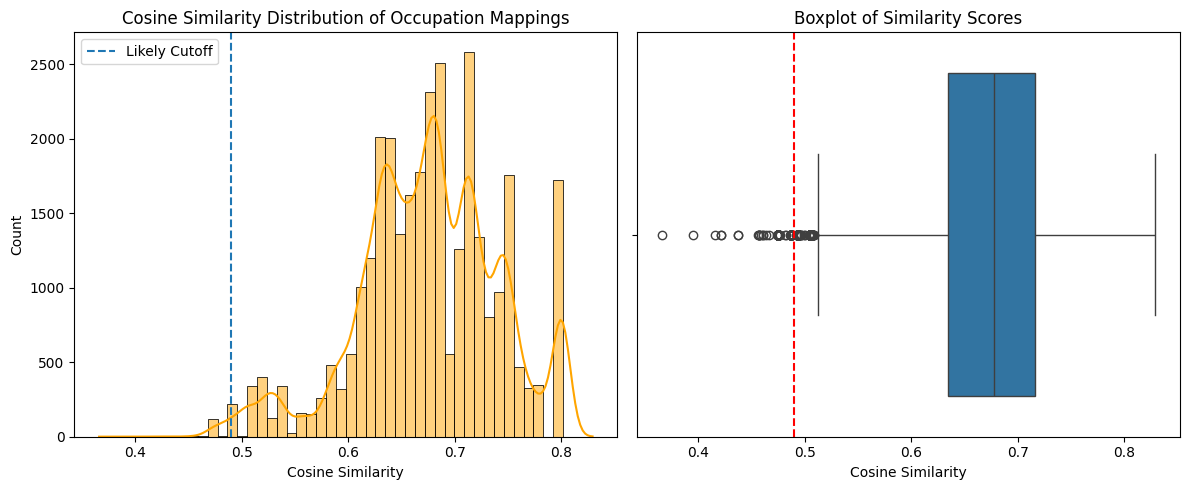

In [65]:
data = df_unified_resume_mapped['Similarity_Score']

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(data, bins=50, kde=True, color='orange', ax=axes[0])
axes[0].axvline(0.49, linestyle='--', label='Likely Cutoff')
axes[0].set_title("Cosine Similarity Distribution of Occupation Mappings")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot
sns.boxplot(x=data, ax=axes[1])
axes[1].axvline(0.49, linestyle='--', color='red')
axes[1].set_title("Boxplot of Similarity Scores")
axes[1].set_xlabel("Cosine Similarity")

plt.tight_layout()
plt.show()

In [71]:
# Display the low-scoring mappings for manual review
df_unified_resume_mapped[df_unified_resume_mapped['Similarity_Score'] < 0.49].sort_values('Similarity_Score', ascending=False)

,Occupation,Resume_Text,Mapped_ONET_Code,Mapped_ONET_Title,Similarity_Score
2417,Ios Developer,philip arnold harrisontracy . 513.789.5267x476...,17-3019.00,"Drafters, All Other",0.487600
2418,Ios Developer,tyler mata md karen57 . 749.422.7161 lake vane...,17-3019.00,"Drafters, All Other",0.487600
2419,Ios Developer,jessica thomas reidkimberly .net 307 392 0912x...,17-3019.00,"Drafters, All Other",0.487600
2420,Ios Developer,daniel alvarez lutzallen .net 526 982 5638 cor...,17-3019.00,"Drafters, All Other",0.487600
2422,Ios Developer,brad brown dvm ybooth . 530 205 6719x9163 lake...,17-3019.00,"Drafters, All Other",0.487600
...,...,...,...,...,...
7115,PRESIDENT,executive media relations pro compelling pitch...,13-1161.00,Market Research Analysts and Marketing Special...,0.421618
7026,PRESIDENT,career focus creative marketing professional m...,13-1161.00,Market Research Analysts and Marketing Special...,0.421618
6493,CO-OWNER/MANAGER/ CHEF,professional thank advance allowing respond am...,35-2013.00,"Cooks, Private Household",0.416027
6088,DOMESTIC VIOLENCE AND SEXUAL ASSAULT ADVOCATE,professional certified massachusetts domestic ...,33-1099.00,First-Line Supervisors of Protective Service W...,0.394836


In [72]:
# Filter low similarity
print(f"Rows Dropped due to low Similarity Score: {(df_unified_resume_mapped['Similarity_Score'] < 0.49).sum()}")
df_unified_resume_mapped = df_unified_resume_mapped[df_unified_resume_mapped['Similarity_Score'] >= 0.49]

# Save the dataset for Semantic Ontology Alignment
df_unified_resume_mapped.to_csv('df_unified_resume_mapped.csv', index=False)

print('\n')
df_unified_resume_mapped.info()

Rows Dropped due to low Similarity Score: 240


<class 'pandas.core.frame.DataFrame'>
Index: 31225 entries, 0 to 33871
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Occupation         31225 non-null  object 
 1   Resume_Text        31225 non-null  object 
 2   Mapped_ONET_Code   31225 non-null  object 
 3   Mapped_ONET_Title  31225 non-null  object 
 4   Similarity_Score   31225 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.4+ MB


## Semantic Ontology Alignment

In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import CountVectorizer


# CONFIGURATION
RESUME_FILE = 'df_unified_resume_mapped.csv'
ONET_ONTOLOGY_FILE = 'master_vocab.pkl'

THRESHOLDS = [0.62, 0.67, 0.72, 0.77, 0.82]
SAMPLE_SIZE = 100
TOLERANCE_RATIO = 0.25   # controls how close to mean word count


# INITIALIZE MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

aligner = SentenceTransformer('all-mpnet-base-v2').to(device)


# TEXT PROCESSING HELPERS
def preserve_tech_syntax(text: str) -> str:
    """
    Normalize text while preserving technical tokens like C++, C#, .NET.
    """
    if not isinstance(text, str):
        return ""
    return ' '.join(
        re.sub(r'[^a-z0-9\+\#\.]', ' ', text.lower()).split()
    )


def extract_ngrams(text: str, ngram_range=(1, 3)) -> list:
    """
    Extract 1–3 gram phrases from a single document.
    """
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words='english',
        token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*'
    )
    try:
        vectorizer.fit([text])
        return vectorizer.get_feature_names_out().tolist()
    except ValueError:
        return []


# LOAD DATA
print("\nLoading datasets...")

df_raw = pd.read_csv(RESUME_FILE)

if 'Resume_Text' not in df_raw.columns:
    raise ValueError("Column 'Resume_Text' not found.")

with open(ONET_ONTOLOGY_FILE, "rb") as f:
    master_vocab = pickle.load(f)
print(f"Extracted {len(master_vocab)} unique O*NET competencies.")

print("Precomputing O*NET Ontology Embeddings...")

# PRECOMPUTE ONTOLOGY EMBEDDINGS (CRITICAL FOR SPEED)
print("Encoding ontology...")
ontology_embs = aligner.encode(
    master_vocab,
    convert_to_tensor=True,
    device=device
)


# PREPARE RESUME SAMPLE 
print("\nPreparing controlled sample...")

df_raw['Cleaned'] = df_raw['Resume_Text'].apply(preserve_tech_syntax)
df_raw['Word_Count'] = df_raw['Cleaned'].apply(lambda x: len(x.split()))

mean_wc = df_raw['Word_Count'].mean()
std_wc = df_raw['Word_Count'].std()

print(f"Mean word count: {mean_wc:.2f}, Std: {std_wc:.2f}")

# Select resumes near mean (avoid bias from very short/long resumes)
tolerance = TOLERANCE_RATIO * std_wc

df_filtered = df_raw[
    (df_raw['Word_Count'] >= mean_wc - tolerance) &
    (df_raw['Word_Count'] <= mean_wc + tolerance)
]

# Fallback if too few samples
if len(df_filtered) < SAMPLE_SIZE:
    print("⚠️ Not enough near-mean samples, using full dataset.")
    df_filtered = df_raw

df_sample = df_filtered.sample(n=SAMPLE_SIZE, random_state=42)


# 7. ALIGNMENT FUNCTION
def compute_alignment_metrics(text: str, threshold: float):
    """
    Returns:
    - aligned word count
    - average cosine score of accepted matches
    - number of accepted matches
    """
    chunks = extract_ngrams(text)

    if not chunks:
        return 0, 0.0, 0

    chunk_embs = aligner.encode(
        chunks,
        convert_to_tensor=True,
        device=device
    )

    cosine_scores = util.cos_sim(chunk_embs, ontology_embs)
    max_scores, max_indices = torch.max(cosine_scores, dim=1)

    accepted_scores = []
    aligned_terms = []

    for i, score in enumerate(max_scores):
        val = score.item()
        if val >= threshold:
            accepted_scores.append(val)
            aligned_terms.append(master_vocab[max_indices[i].item()])

    # remove duplicates to avoid inflation
    aligned_terms = list(set(aligned_terms))

    word_count = len(" ".join(aligned_terms).split())
    avg_cosine = np.mean(accepted_scores) if accepted_scores else 0.0
    match_count = len(accepted_scores)

    return word_count, avg_cosine, match_count


# RUN EXPERIMENT
print("\nRunning threshold comparison...")

results = {}

for th in THRESHOLDS:
    lengths = []
    cosines = []
    matches = []

    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc=f"TH={th}"):

        wc, avg_cos, mc = compute_alignment_metrics(row['Cleaned'], th)

        lengths.append(wc)
        cosines.append(avg_cos)
        matches.append(mc)

    results[th] = {
        "lengths": lengths,
        "cosines": cosines,
        "matches": matches
    }


# SUMMARY STATISTICS
summary = pd.DataFrame({
    th: {
        "mean_word_count": np.mean(results[th]["lengths"]),
        "mean_cosine": np.mean(results[th]["cosines"]),
        "mean_matches": np.mean(results[th]["matches"])
    }
    for th in THRESHOLDS
}).T

print(summary)

Using device: cuda

Loading datasets...
Extracted 366 unique O*NET competencies.
Precomputing O*NET Ontology Embeddings...
Encoding ontology...

Preparing controlled sample...
Mean word count: 304.38, Std: 247.44

Running threshold comparison...


TH=0.82: 100%|██████████| 100/100 [01:15<00:00,  1.33it/s]

      mean_word_count  mean_cosine  mean_matches
0.62            62.36     0.738395         98.93
0.67            49.60     0.783816         69.01
0.72            38.05     0.826785         47.44
0.77            26.04     0.877913         30.81
0.82            18.27     0.927813         19.53


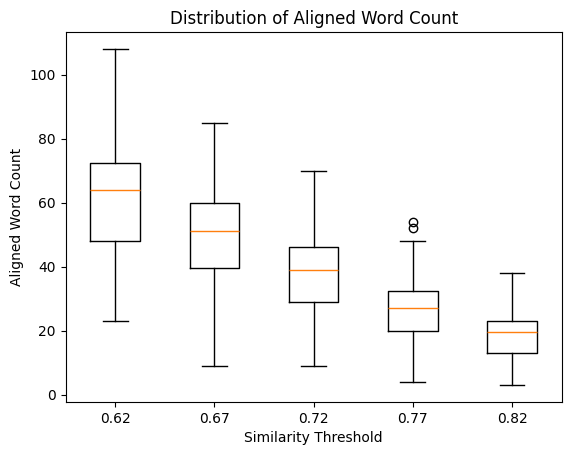

In [ ]:
# 10. VISUALIZATION
# Distribution (more informative than mean)
plt.figure()

plt.boxplot(
    [results[th]["lengths"] for th in THRESHOLDS],
    tick_labels=THRESHOLDS
)

plt.xlabel("Similarity Threshold")
plt.ylabel("Aligned Word Count")
plt.title("Distribution of Aligned Word Count")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import torch
import pickle
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm

# CONFIGURATION & FILE PATHS
OUTPUT_FILE = 'df_unified_resume_mapped_aligned.csv'
RAW_RESUME_FILE = 'df_unified_resume_mapped.csv'
ONET_ONTOLOGY_FILE = 'master_vocab.pkl'

# Set the similarity threshold
SIMILARITY_THRESHOLD = 0.72

# Save progress to disk every X resumes
CHECKPOINT_INTERVAL = 1000

# INITIALIZE MODEL & DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Initializing S-BERT on device: {device}")
aligner = SentenceTransformer('all-mpnet-base-v2').to(device)

# HELPER FUNCTIONS
def preserve_tech_syntax(text: str) -> str:
    """Cleans text while preserving vital tech syntax like C++, C#, .NET."""
    if not isinstance(text, str): return ""
    return ' '.join(re.sub(r'[^a-z0-9\+\#\.]', ' ', str(text).lower()).split())

def extract_ngrams(text: str, ngram_range=(1,3)) -> list:
    """Extracts 1 to 3-word chunks from a single resume to compare against O*NET."""
    vectorizer = CountVectorizer(ngram_range=ngram_range,
                                 stop_words='english',
                                token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*')
    try:
        vectorizer.fit([text])
        return vectorizer.get_feature_names_out().tolist()
    except ValueError:
        return []

sample = "C C++ C# .NET SQL Python Node.js ASP.NET"
print(extract_ngrams(sample))

# LOAD DATA & PREPARE ONTOLOGY
print("\nLoading dataset and checking for checkpoints...")

# --- CHECKPOINT RESUMPTION LOGIC ---
if os.path.exists(OUTPUT_FILE):
    print(f"⚠️ Found existing checkpoint file '{OUTPUT_FILE}'. Resuming progress...")
    df_raw = pd.read_csv(OUTPUT_FILE, keep_default_na=False)
else:
    print(f"Starting fresh from '{RAW_RESUME_FILE}'...")
    df_raw = pd.read_csv(RAW_RESUME_FILE)
    # Initialize the target column with a specific placeholder
    df_raw['Aligned_Text'] = "__UNPROCESSED__"

# Check if target column exists
if 'Resume_Text' not in df_raw.columns:
    raise ValueError(f"Column 'Resume_Text' not found. Please rename your text column.")

# Load Ontology
with open(ONET_ONTOLOGY_FILE, "rb") as f:
    master_vocab = pickle.load(f)
print(f"Extracted {len(master_vocab)} unique O*NET competencies.")

print("Precomputing O*NET Ontology Embeddings...")
ontology_embs = aligner.encode(master_vocab, convert_to_tensor=True, device=device)

# THE DETERMINISTIC ALIGNER CORE
def align_resume_to_ontology(messy_text: str) -> str:
    """Maps messy resume text to official O*NET dictionary using S-BERT."""
    cleaned = preserve_tech_syntax(messy_text)
    chunks = extract_ngrams(cleaned)

    if not chunks:
        return ""

    chunk_embs = aligner.encode(chunks, convert_to_tensor=True, device=device)
    cosine_scores = util.cos_sim(chunk_embs, ontology_embs)

    aligned = set()
    max_scores, max_indices = torch.max(cosine_scores, dim=1)

    for i, score in enumerate(max_scores):
        if score.item() >= SIMILARITY_THRESHOLD:
            aligned.add(master_vocab[max_indices[i].item()])

    return ' '.join(sorted(aligned))

# EXECUTION WITH CHECKPOINTS
# Identify indices that have not been processed yet
unprocessed_mask = df_raw['Aligned_Text'] == "__UNPROCESSED__"
unprocessed_indices = df_raw[unprocessed_mask].index

print(f"\n--- EXECUTION STATUS ---")
print(f"Total rows in dataset: {len(df_raw)}")
print(f"Rows already processed: {len(df_raw) - len(unprocessed_indices)}")
print(f"Rows remaining: {len(unprocessed_indices)}")

if len(unprocessed_indices) > 0:
    print("\nStarting Semantic Alignment Pipeline...")

    # Initialize progress bar for the remaining rows
    pbar = tqdm(total=len(unprocessed_indices), desc="Aligning Resumes", unit="resume")

    for count, idx in enumerate(unprocessed_indices, start=1):
        resume_text = df_raw.at[idx, 'Resume_Text']
        # resume_text = df_raw.at[idx, 'Skill_Text']

        # Run alignment and update dataframe in-place
        df_raw.at[idx, 'Aligned_Text'] = align_resume_to_ontology(resume_text)
        pbar.update(1)

        # Trigger checkpoint save
        if count % CHECKPOINT_INTERVAL == 0:
            df_raw.to_csv(OUTPUT_FILE, index=False)

    pbar.close()

    # Final guaranteed save after exiting loop
    df_raw.to_csv(OUTPUT_FILE, index=False)
    print(f"\nAlignment complete! Final dataset successfully saved to '{OUTPUT_FILE}'.")
else:
    print(f"\nDataset is already 100% aligned in '{OUTPUT_FILE}'. No action needed.")

Initializing S-BERT on device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

['.net', '.net sql', '.net sql python', 'asp.net', 'c', 'c c++', 'c c++ c#', 'c#', 'c# .net', 'c# .net sql', 'c++', 'c++ c#', 'c++ c# .net', 'node.js', 'node.js asp.net', 'python', 'python node.js', 'python node.js asp.net', 'sql', 'sql python', 'sql python node.js']

Loading dataset and checking for checkpoints...
Starting fresh from '/content/drive/MyDrive/Colab Notebooks/df_unified_resume_mapped.csv'...
Extracted 366 unique O*NET competencies.
Precomputing O*NET Ontology Embeddings...

--- EXECUTION STATUS ---
Total rows in dataset: 31330
Rows already processed: 0
Rows remaining: 31330

Starting Semantic Alignment Pipeline...


Aligning Resumes: 100%|██████████| 31330/31330 [4:05:33<00:00,  2.13resume/s]



Alignment complete! Final dataset successfully saved to '/content/drive/MyDrive/Colab Notebooks/df_unified_resume_mapped_aligned.csv'.


In [77]:
df_aligned = pd.read_csv('df_unified_resume_mapped_aligned.csv')
df_aligned.head()

,Occupation,Resume_Text,Mapped_ONET_Code,Mapped_ONET_Title,Similarity_Score,Aligned_Text
0,DEALERSHIP FINANCE MANAGER,dealership finance manager 03 2011 current sta...,53-3099.00,"Motor Vehicle Operators, All Other",0.492201,communications and media economics and account...
1,VP OF BUSINESS DEVELOPMENT,professional accomplished business development...,15-2051.02,Clinical Data Managers,0.493218,administration and management biology c coordi...
2,AR/VR Developer,s sample nicholas robinson nicholas robinson c...,15-1255.01,Video Game Designers,0.493576,apple ios apple macos autodesk maya c# design ...
3,AR/VR Developer,s professional robert middleton tailored ar vr...,15-1255.01,Video Game Designers,0.493576,apple macos autodesk maya c c# c++ design educ...
4,AR/VR Developer,professional matthew simpson matthew simpson c...,15-1255.01,Video Game Designers,0.493576,c c# design education and training programming...


In [78]:
df_aligned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31225 entries, 0 to 31224
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Occupation         31225 non-null  object 
 1   Resume_Text        31225 non-null  object 
 2   Mapped_ONET_Code   31225 non-null  object 
 3   Mapped_ONET_Title  31225 non-null  object 
 4   Similarity_Score   31225 non-null  float64
 5   Aligned_Text       31207 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.4+ MB


### Aligned_Text Cleaning

In [ ]:
# 5. POST-PROCESSING CLEANUP
# Original row count
original_rows = len(df_aligned)

# Count empty / NaN / whitespace-only Aligned_Text rows
empty_mask = (
    df_aligned['Aligned_Text'].isna() |
    (df_aligned['Aligned_Text'].astype(str).str.strip() == '')
)
empty_dropped = empty_mask.sum()

# Remove empty rows first
df_unified_resume_mapped_aligned = df_aligned.loc[~empty_mask].copy()

# Count duplicates based on Aligned_Text + Mapped_ONET_Code
duplicate_mask = df_unified_resume_mapped_aligned.duplicated(
    subset=['Aligned_Text'],
    keep='first'
)
duplicates_dropped = duplicate_mask.sum()

# Remove duplicates
df_unified_resume_mapped_aligned = df_unified_resume_mapped_aligned.loc[~duplicate_mask].copy()

# Final row count
final_rows = len(df_unified_resume_mapped_aligned)

# Show summary
print(f"Original rows                   : {original_rows:,}")
print(f"Empty Aligned_Text dropped      : {empty_dropped:,}")
print(f"Duplicated Aligned_Text dropped : {duplicates_dropped:,}")
print(f"Final rows                      : {final_rows:,}")
print('\n')
# Inspect dataframe
df_unified_resume_mapped_aligned.info()

Original rows                   : 31,225
Empty Aligned_Text dropped      : 18
Duplicated Aligned_Text dropped : 1,364
Final rows                      : 29,843


<class 'pandas.core.frame.DataFrame'>
Index: 29843 entries, 0 to 31224
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Occupation         29843 non-null  object 
 1   Resume_Text        29843 non-null  object 
 2   Mapped_ONET_Code   29843 non-null  object 
 3   Mapped_ONET_Title  29843 non-null  object 
 4   Similarity_Score   29843 non-null  float64
 5   Aligned_Text       29843 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.6+ MB


### Save Dataset for Recommendation System Use (as it does not need salary mapping)

In [80]:
# Save dataset for Recommendation System use
# Recommendation System needs complete data and complete O*NET code for more precise evaluation
df_unified_resume_mapped_aligned.to_csv(
    "df_unified_resume_mapped_aligned.csv",
    index=False
)
print('Dataset saved.')

Dataset saved.


## Data Preprocessing (Continue) (For Salary Prediction Model)

In [187]:
# Read back the aligned dataset
df_unified_resume_mapped_aligned = pd.read_csv("df_unified_resume_mapped_aligned.csv")

# Clean for low data occupations
print(f"--- BEFORE CLEANING ---")
print(f"Total Resumes: {len(df_unified_resume_mapped_aligned)}")
print(f"Total Unique Occupations: {df_unified_resume_mapped_aligned['Mapped_ONET_Code'].nunique()}")

# 2. Set your statistical threshold
MINIMUM_RESUMES = 30

# 3. Count how many resumes exist per occupation
occ_counts = df_unified_resume_mapped_aligned['Mapped_ONET_Code'].value_counts()

# 4. Identify the occupations that survive the cutoff
valid_codes = occ_counts[occ_counts >= MINIMUM_RESUMES].index

# 5. Filter the dataset to keep ONLY those valid occupations
df_unified_resume_mapped_aligned_cleaned = df_unified_resume_mapped_aligned[df_unified_resume_mapped_aligned['Mapped_ONET_Code'].isin(valid_codes)].copy()

print(f"\n--- AFTER CLEANING ---")
print(f"Minimum Threshold Used: {MINIMUM_RESUMES}")
print(f"Occupations Dropped due to low data: {len(occ_counts) - len(valid_codes)}")
print(f"Total Resumes Kept: {len(df_unified_resume_mapped_aligned_cleaned)}")
print(f"Total Unique Occupations Kept: {df_unified_resume_mapped_aligned_cleaned['Mapped_ONET_Code'].nunique()}")

--- BEFORE CLEANING ---
Total Resumes: 29843
Total Unique Occupations: 314

--- AFTER CLEANING ---
Minimum Threshold Used: 30
Occupations Dropped due to low data: 255
Total Resumes Kept: 28975
Total Unique Occupations Kept: 59


In [188]:
df_salary = pd.read_csv("all_data_M_2024.csv", low_memory=False)

### Resume Mapping to Annual Median Salary

In [189]:
# Prepare OEWS Wage Dataset
df_salary_sub = (
    df_salary[
        (df_salary["AREA"] == 99) &      # AREA == 99 : national-level wage
        (df_salary["NAICS"] == "0")      # NAICS == 0 : all industries aggregated
    ][["OCC_CODE", "A_MEDIAN"]]          # Get O*NET SOC Code and Annual Median Salary only
    .drop_duplicates(subset="OCC_CODE", keep='first')  # Keep first, remove the rest duplicated
    .reset_index(drop=True)
)

# Transform to numeric
df_salary_sub['A_MEDIAN'] = pd.to_numeric(df_salary_sub['A_MEDIAN'], errors='coerce')

# Remove last 3 characters (usually .00)
df_unified_resume_mapped_aligned_cleaned['Mapped_ONET_Code'] = df_unified_resume_mapped_aligned_cleaned['Mapped_ONET_Code'].str \
                                                         .replace(r'\.\d{2}$', '', regex=True)

# Perform Merging
df_unified_salary = df_unified_resume_mapped_aligned_cleaned.merge(df_salary_sub, 
                                            left_on='Mapped_ONET_Code', 
                                            right_on='OCC_CODE', 
                                            how='left')

# Drop rows where Annual_Median_Salary is missing / not merged
df_unified_salary.dropna(subset=['A_MEDIAN'], inplace=True)

# Name Standardization
df_unified_salary.rename(columns={'A_MEDIAN': 'Annual_Median_Salary'}, inplace=True)

# Create a Log Salary column
df_unified_salary['Log_Salary'] = np.log(df_unified_salary['Annual_Median_Salary'])

print("Annual Median Salary mapped to the dataset.")

Annual Median Salary mapped to the dataset.


In [190]:
df_unified_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28975 entries, 0 to 28974
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Occupation            28975 non-null  object 
 1   Resume_Text           28975 non-null  object 
 2   Mapped_ONET_Code      28975 non-null  object 
 3   Mapped_ONET_Title     28975 non-null  object 
 4   Similarity_Score      28975 non-null  float64
 5   Aligned_Text          28975 non-null  object 
 6   OCC_CODE              28975 non-null  object 
 7   Annual_Median_Salary  28975 non-null  float64
 8   Log_Salary            28975 non-null  float64
dtypes: float64(3), object(6)
memory usage: 2.0+ MB


### Underrepresented Classes Filtering

In [192]:
# 1. Show current distribution before capping
print("=== Original Distribution (Top 15) ===")
original_counts = df_unified_salary['OCC_CODE'].value_counts()

print(original_counts.head(15))
print(f"Total Resumes: {len(df_unified_salary)}")

=== Original Distribution (Top 15) ===
OCC_CODE
15-1299    3543
15-1252    2371
15-1254    1599
41-4011    1246
15-2051    1242
15-1221    1199
15-1244    1103
11-9199    1006
15-1255    1005
15-1242    1000
13-1071     970
15-1243     837
15-1231     766
13-1199     749
27-3031     664
Name: count, dtype: int64
Total Resumes: 28975


In [193]:
# 1. Calculate the counts for every occupation
occ_counts = df_unified_salary['OCC_CODE'].value_counts()

# 2. Define a rigorous statistical ceiling of 80%
dynamic_cap = int(np.percentile(occ_counts, 80))

print(f"Calculated 80th Percentile Cap: {dynamic_cap} resumes")

# 3. Apply the dynamic cap
df_balanced = (
    df_unified_salary.groupby('OCC_CODE', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), dynamic_cap), random_state=42))
    .reset_index(drop=True)
)

Calculated 80th Percentile Cap: 943 resumes


C:\Users\cjc72\AppData\Local\Temp\ipykernel_20984\3829526082.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), dynamic_cap), random_state=42))


In [194]:
# 3. Show new distribution after capping
print("=== After Downsampling (Top 15) ===")
balanced_counts = df_balanced['OCC_CODE'].value_counts()

print(balanced_counts.head(15))
print(f"Total Resumes: {len(df_balanced)}")

=== After Downsampling (Top 15) ===
OCC_CODE
15-1221    943
15-1242    943
13-1071    943
11-9199    943
15-1244    943
15-1255    943
41-4011    943
15-2051    943
15-1299    943
15-1252    943
15-1254    943
15-1243    837
15-1231    766
13-1199    749
27-3031    664
Name: count, dtype: int64
Total Resumes: 23064


In [136]:
df_unified_salary = df_balanced.copy()
df_unified_salary.describe()

,Similarity_Score,Annual_Median_Salary,Log_Salary
count,23064.000000,23064.000000,23064.000000
mean,0.683522,97708.638137,11.437640
std,0.063962,30194.415704,0.333696
min,0.493576,34580.000000,10.451031
25%,0.645913,72910.000000,11.196981
50%,0.684271,98090.000000,11.493641
75%,0.725975,112590.000000,11.631508
max,0.800000,171200.000000,12.050588


In [137]:
# Select final columns
df_unified_salary_final = df_unified_salary[['Aligned_Text','Annual_Median_Salary', 'Log_Salary', 'OCC_CODE']]

# Save final dataset
df_unified_salary_final.to_csv('Unified_Resume_Salary_Dataset_ori.csv', index=False)


## Data Understanding

In [148]:
print("Dataset shape:", df_unified_salary_final.shape)
print(df_unified_salary_final.head())
print(df_unified_salary_final.info())
print(df_unified_salary_final.describe())

Dataset shape: (23064, 4)
                                        Aligned_Text  Annual_Median_Salary  \
0  administration and management administrative e...              161030.0   
1  administration and management adobe after effe...              161030.0   
2  administration and management administrative c...              161030.0   
3  administration and management biology communic...              161030.0   
4  administration and management communications a...              161030.0   

   Log_Salary OCC_CODE  
0   11.989346  11-2021  
1   11.989346  11-2021  
2   11.989346  11-2021  
3   11.989346  11-2021  
4   11.989346  11-2021  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23064 entries, 0 to 23063
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Aligned_Text          23064 non-null  object 
 1   Annual_Median_Salary  23064 non-null  float64
 2   Log_Salary            23064 non-null  

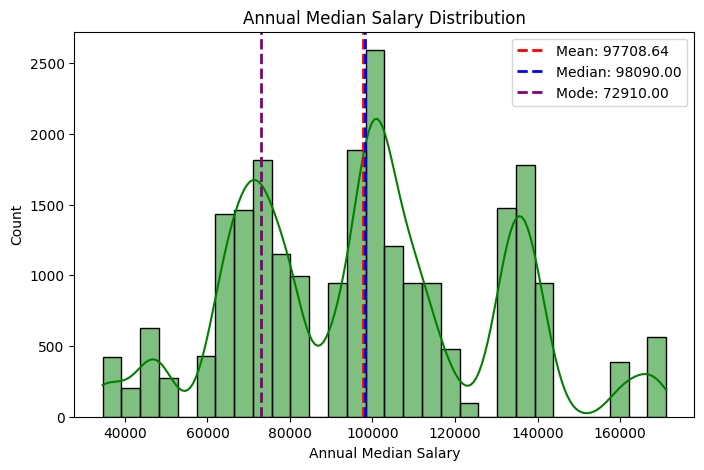

In [146]:
mean_val = df_unified_salary_final['Annual_Median_Salary'].mean()
median_val = df_unified_salary_final['Annual_Median_Salary'].median()
mode_val = df_unified_salary_final['Annual_Median_Salary'].mode().iloc[0]   

plt.figure(figsize=(8,5))

sns.histplot(df_unified_salary_final['Annual_Median_Salary'], bins=30, kde=True, color='green')

# Mean
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_val:.2f}")

# Median
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f"Median: {median_val:.2f}")

# Mode
plt.axvline(mode_val, color='purple', linestyle='--', linewidth=2, label=f"Mode: {mode_val:.2f}")

plt.title("Annual Median Salary Distribution")
plt.xlabel("Annual Median Salary")
plt.ylabel("Count")
plt.legend()
plt.show()

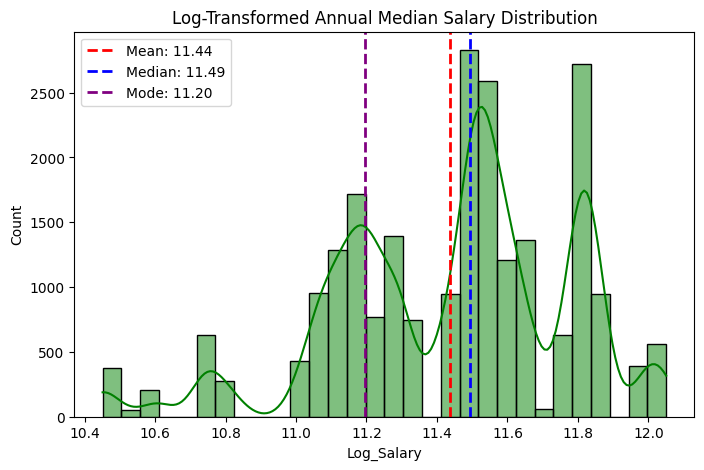

In [152]:
mean_val = df_unified_salary_final['Log_Salary'].mean()
median_val = df_unified_salary_final['Log_Salary'].median()
mode_val = df_unified_salary_final['Log_Salary'].mode().iloc[0]   

plt.figure(figsize=(8,5))

sns.histplot(df_unified_salary_final['Log_Salary'], bins=30, kde=True, color='green')

# Mean
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_val:.2f}")

# Median
plt.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f"Median: {median_val:.2f}")

# Mode
plt.axvline(mode_val, color='purple', linestyle='--', linewidth=2, label=f"Mode: {mode_val:.2f}")

plt.title("Log-Transformed Annual Median Salary Distribution")
plt.xlabel("Log_Salary")
plt.ylabel("Count")
plt.legend()
plt.show()

C:\Users\cjc72\AppData\Local\Temp\ipykernel_20984\4013204828.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unified_salary_final['Word_Count'] = df_unified_salary_final['Aligned_Text'].apply(lambda x: len(str(x).split()))


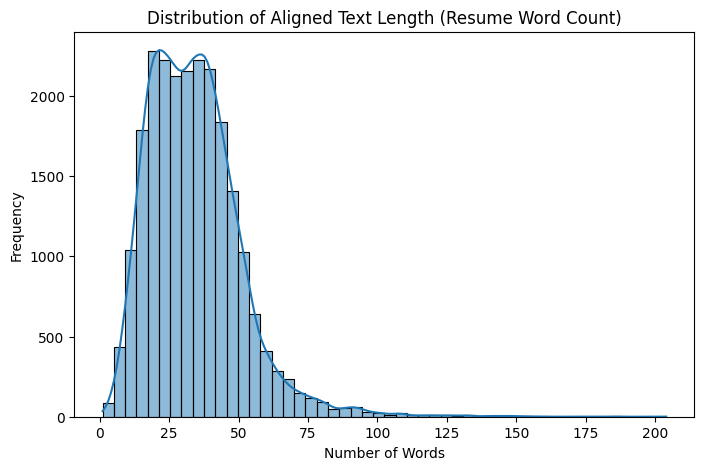

In [156]:
df_unified_salary_final['Word_Count'] = df_unified_salary_final['Aligned_Text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(df_unified_salary_final['Word_Count'], bins=50, kde=True)
plt.title('Distribution of Aligned Text Length (Resume Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

C:\Users\cjc72\AppData\Local\Temp\ipykernel_20984\412894915.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unified_salary_final['Word_Count_Bin'] = pd.cut(
C:\Users\cjc72\AppData\Local\Temp\ipykernel_20984\412894915.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


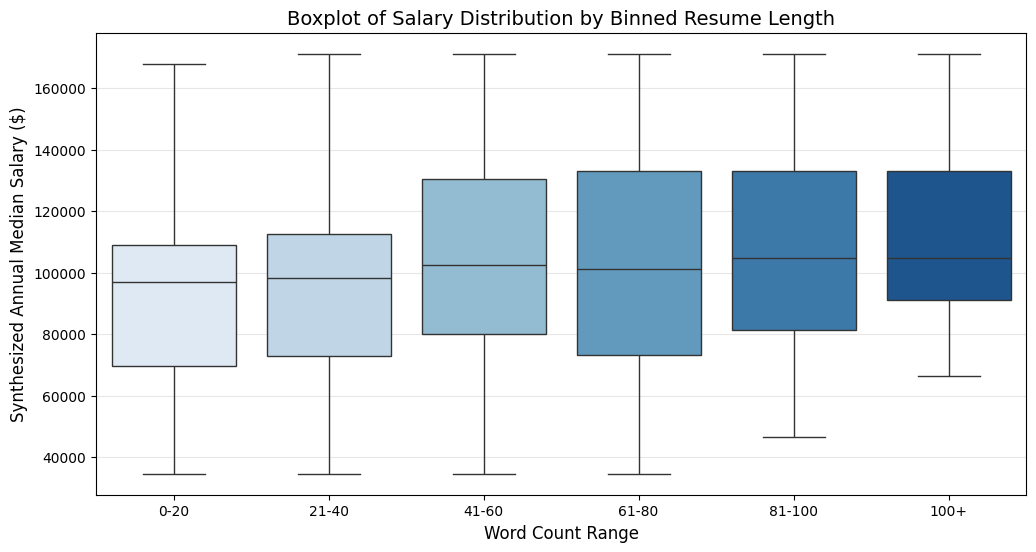

In [157]:
# 1. Create specific bins based on data distribution
bins = [0, 20, 40, 60, 80, 100, np.inf]
labels = ['0-20', '21-40', '41-60', '61-80', '81-100', '100+']

df_unified_salary_final['Word_Count_Bin'] = pd.cut(
    df_unified_salary_final['Word_Count'], 
    bins=bins, 
    labels=labels
)

# 2. OPTION A: Box Plot (Best for distribution & outliers)
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_unified_salary_final, 
    x='Word_Count_Bin', 
    y='Annual_Median_Salary',
    palette="Blues"
)
plt.title('Boxplot of Salary Distribution by Binned Resume Length', fontsize=14)
plt.xlabel('Word Count Range', fontsize=12)
plt.ylabel('Synthesized Annual Median Salary ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\cjc72\AppData\Local\Temp\ipykernel_20984\1575173267.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


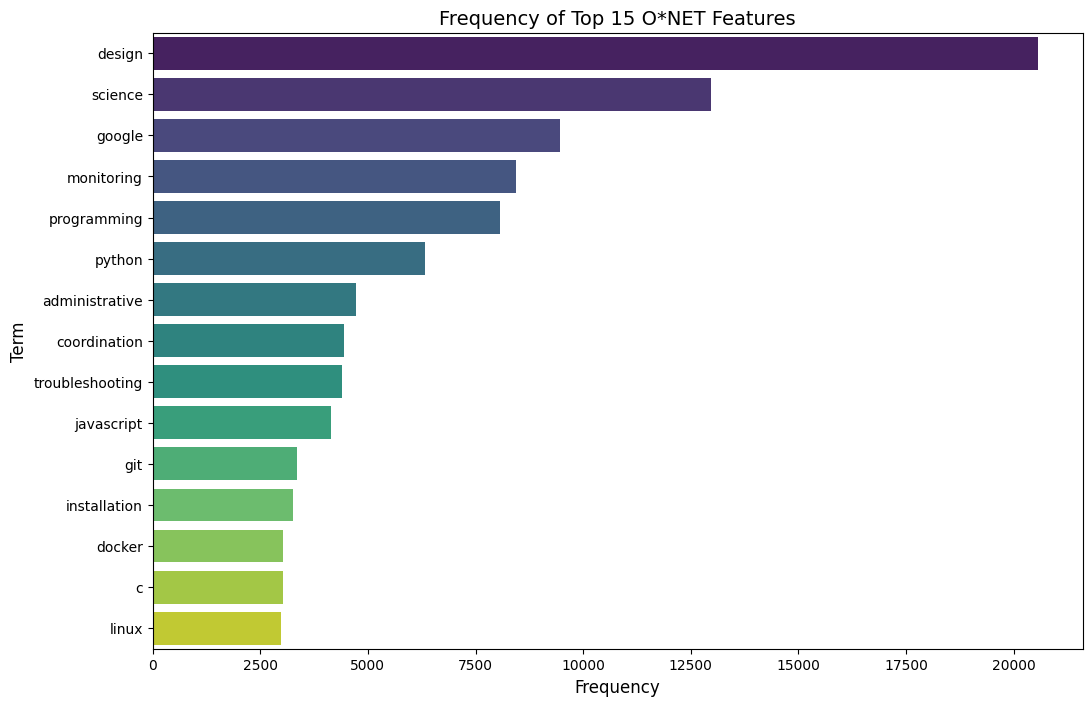

In [168]:

# 1. Load your master vocabulary
# Ensure master_vocab is either a list of terms or a dictionary {term: index}
with open('master_vocab.pkl', 'rb') as f:
    master_vocab = pickle.load(f)

# 2. Initialize Vectorizer with fixed vocabulary
# Note: min_df is ignored when a custom vocabulary is provided
vectorizer = CountVectorizer(
    vocabulary=master_vocab,
    stop_words='english',
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*'
)

# 3. Transform the text
X = vectorizer.fit_transform(df_unified_salary_final['Aligned_Text'].astype(str))
vocab_counts = X.sum(axis=0).A1
vocab_names = vectorizer.get_feature_names_out()

# 4. Identify Top 15 Frequency
top_idx = vocab_counts.argsort()[-15:][::-1]

# 5. Visualization
plt.figure(figsize=(12, 8))
sns.barplot(
    x=vocab_counts[top_idx],
    y=[vocab_names[i] for i in top_idx],
    palette="viridis"
)
plt.title('Frequency of Top 15 O*NET Features', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Term', fontsize=12)
plt.show()

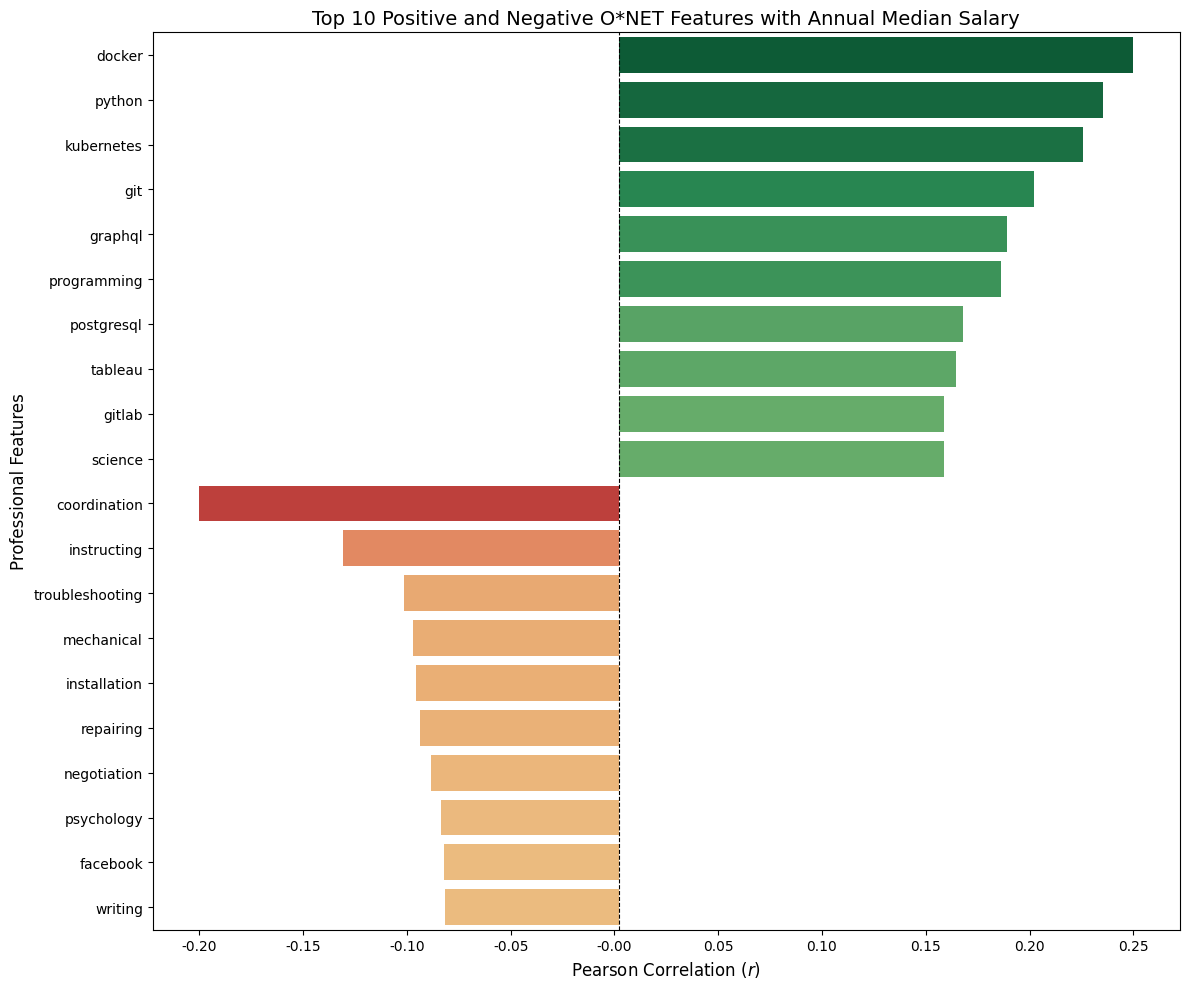

In [177]:
# 1. SETUP & DATA LOADING
# Assuming df_unified_salary_final is defined
texts = df_unified_salary_final['Aligned_Text'].astype(str)
salary = df_unified_salary_final['Annual_Median_Salary'].values

with open('master_vocab.pkl', 'rb') as f:
    master_vocab = pickle.load(f)

# 2. TF-IDF VECTORIZATION
vectorizer = TfidfVectorizer(
    vocabulary=master_vocab,
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*' 
)

X = vectorizer.fit_transform(texts)
feature_names = np.array(vectorizer.get_feature_names_out())

# 3. CORRELATION ANALYSIS
correlations = []
for i in range(X.shape[1]):
    word_scores = X[:, i].toarray().ravel()
    if np.std(word_scores) == 0:
        correlations.append((feature_names[i], 0.0, 1.0))
        continue
    corr, p = pearsonr(word_scores, salary)
    correlations.append((feature_names[i], corr, p))

corr_df = pd.DataFrame(correlations, columns=['Features', 'Correlation', 'P_Value'])
significant_corr = corr_df[corr_df['P_Value'] < 0.05]

top_pos = significant_corr.sort_values('Correlation', ascending=False).head(10)
top_neg = significant_corr.sort_values('Correlation', ascending=True).head(10)
plot_df = pd.concat([top_pos, top_neg])

# 4. GRADIENT PLOTTING (FIXED WARNINGS)
plt.figure(figsize=(12, 10))

# FIX 1: Use matplotlib.colormaps directly instead of deprecated get_cmap
v_abs_max = max(abs(plot_df['Correlation'].min()), abs(plot_df['Correlation'].max()))
norm = plt.Normalize(vmin=-v_abs_max, vmax=v_abs_max)
cmap = mpl.colormaps['RdYlGn'] 
colors = [cmap(norm(x)) for x in plot_df['Correlation']]

# FIX 2: Assign 'Features' to hue and set legend=False to avoid FutureWarning
sns.barplot(
    x='Correlation',
    y='Features',
    data=plot_df,
    hue='Features', 
    palette=colors,
    legend=False
)

plt.title('Top 10 Positive and Negative O*NET Features with Annual Median Salary', fontsize=14)
plt.xlabel('Pearson Correlation ($r$)', fontsize=12)
plt.ylabel('Professional Features', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

min_val, max_val = plot_df['Correlation'].min(), plot_df['Correlation'].max()
plt.xticks(
    ticks=np.linspace(min_val, max_val, num=10),
    labels=[f"{x:.2f}" for x in np.linspace(min_val, max_val, num=10)]
)

plt.tight_layout()
plt.show()